# AmbiStory WSD — DeBERTa-v3 Cross-Encoder (Upgraded)

**Key changes vs `bert-solver-embedding-change.ipynb`:**
1. **Unfrozen DeBERTa-v3-base** — full fine-tuning with differential LRs
   (2e-5 for transformer body, 1e-3 for MLP head)
2. **Base model upgraded** to `microsoft/deberta-v3-base`
3. **[CLS]-pooled Cross-Encoder** — input `[CLS] story [SEP] definition [SEP]`,
   single [CLS] vector feeds the MLP; no separate bi-encoder stage
4. **Linear warmup scheduler** (first 10 % of steps) then linear decay to 0
5. **Leakage-free folds** — PCA fit inside fold-train only; DeBERTa fine-tuned
   inside each fold; val data never touches any fitting step

## Cell 1 — Install

In [1]:
import subprocess, sys
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q',
     'transformers', 'accelerate', 'sentencepiece', 'protobuf',
     'optuna', 'scipy', 'scikit-learn', 'tqdm'],
    check=True
)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'transformers', 'accelerate', 'sentencepiece', 'protobuf', 'optuna', 'scipy', 'scikit-learn', 'tqdm'], returncode=0)

## Cell 2 — Imports, Config, Logger

In [2]:
import json, os, re, time, warnings, hashlib, copy
from collections import defaultdict, Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.decomposition import PCA
from scipy.stats import spearmanr
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Paths ───────────────────────────────────────────────────────────────────
# Update this to your Kaggle dataset path
DATA = Path('/kaggle/input/datasets/shubhadeepmandal/inlp-project')

# ── Config ──────────────────────────────────────────────────────────────────
CFG = dict(
    # --- Model ---
    deberta_model   = 'cross-encoder/nli-deberta-v3-base',
    max_seq_len     = 256,

    # --- Differential learning rates ---
    # Transformer body: very small LR to prevent catastrophic forgetting
    # MLP head: standard LR since it is randomly initialized
    deberta_lr      = 3e-5,
    head_lr         = 3e-4,   # 1e-3 blows up the random MLP head on first batch
    weight_decay    = 1e-2,

    # --- Warmup scheduler ---
    warmup_fraction = 0.10,   # first 10 % of steps used to ramp up LR

    # --- Fine-tuning epochs per fold ---
    ft_epochs       = 5,
    ft_batch_size   = 16,     # keep small; DeBERTa is memory-hungry

    # --- MLP head architecture ---
    mlp_hidden1     = 256,
    mlp_hidden2     = 64,
    mlp_dropout     = 0.3,
    mlp_epochs      = 30,     # MLP-only refinement after encoder warm-up

    # --- Pairwise ranking loss ---
    pairwise_margin = 0.5,
    pairwise_w      = 0.3,

    # --- CV ---
    n_folds         = 5,
    batch_size      = 32,

    # --- Optuna (searches MLP head hparams only) ---
    n_optuna_trials = 30,
    optuna_epochs   = 10,
)

# ── Logger ──────────────────────────────────────────────────────────────────
class Log:
    C = dict(reset='\033[0m', bold='\033[1m', green='\033[92m',
             cyan='\033[96m', yellow='\033[93m', red='\033[91m', dim='\033[2m')

    @staticmethod
    def _t(): return time.strftime('%H:%M:%S')

    @classmethod
    def sep(cls, title=''):
        w = 70
        if title:
            pad  = (w - len(title) - 2) // 2
            rpad = w - len(title) - 2 - pad
            print(f"\n{cls.C['bold']}{'='*w}{cls.C['reset']}")
            print(f"{cls.C['bold']}{'='*pad} {cls.C['cyan']}{title}"
                  f"{cls.C['reset']}{cls.C['bold']} {'='*rpad}{cls.C['reset']}")
            print(f"{cls.C['bold']}{'='*w}{cls.C['reset']}")
        else:
            print(f"\n{cls.C['dim']}{'-'*w}{cls.C['reset']}")

    @classmethod
    def info(cls, msg): print(f"  {cls.C['dim']}i  [{cls._t()}]{cls.C['reset']}  {msg}")

    @classmethod
    def ok(cls, msg): print(f"  {cls.C['green']}+  [{cls._t()}]{cls.C['reset']}  {msg}")

    @classmethod
    def run(cls, msg):
        print(f"\n  {cls.C['cyan']}>> [{cls._t()}]{cls.C['reset']}  "
              f"{cls.C['bold']}{msg}{cls.C['reset']}")

    @classmethod
    def warn(cls, msg): print(f"  {cls.C['yellow']}!  [{cls._t()}]{cls.C['reset']}  {msg}")

    @classmethod
    def epoch(cls, ep, total, trn_loss, val_spear, val_acc, lr=None):
        w      = 20
        filled = int(w * ep / total)
        bar    = '#' * filled + '.' * (w - filled)
        lr_str = f"  lr: {lr:.2e}" if lr is not None else ''
        print(f"  | [{bar}] Ep {ep:>3}/{total}  "
              f"loss: {cls.C['yellow']}{trn_loss:.4f}{cls.C['reset']}  "
              f"spearman: {cls.C['green']}{val_spear:.4f}{cls.C['reset']}  "
              f"acc_std: {cls.C['cyan']}{val_acc:.4f}{cls.C['reset']}"
              f"{lr_str}")

    @classmethod
    def fold_result(cls, fold, n, spear, acc):
        print(f"\n  {cls.C['bold']}+-- Fold {fold}/{n} "
              f"--------------------------------------------{cls.C['reset']}")
        print(f"  {cls.C['bold']}|{cls.C['reset']}  "
              f"Spearman r : {cls.C['green']}{spear:.4f}{cls.C['reset']}   "
              f"Acc-within-std : {cls.C['cyan']}{acc:.4f}{cls.C['reset']}")
        print(f"  {cls.C['bold']}+----------------------------------------------"
              f"----------{cls.C['reset']}")

    @classmethod
    def final(cls, sp_m, sp_s, acc_m, acc_s):
        print(f"\n{cls.C['bold']}{'='*70}{cls.C['reset']}")
        print(f"  {cls.C['bold']}FINAL CV{cls.C['reset']}  "
              f"Spearman: {cls.C['green']}{sp_m:.4f} +/- {sp_s:.4f}{cls.C['reset']}  "
              f"AccStd: {cls.C['cyan']}{acc_m:.4f} +/- {acc_s:.4f}{cls.C['reset']}")
        print(f"{cls.C['bold']}{'='*70}{cls.C['reset']}\n")


Log.sep('AmbiStory WSD — DeBERTa-v3 Cross-Encoder (Upgraded)')
Log.info(f"Device : {DEVICE}")
Log.info(f"Model  : {CFG['deberta_model']}")
Log.info(f"Transformer LR: {CFG['deberta_lr']}  |  Head LR: {CFG['head_lr']}")


======== AmbiStory WSD — DeBERTa-v3 Cross-Encoder (Upgraded) =========
  i  [20:18:55]  Device : cuda
  i  [20:18:55]  Model  : cross-encoder/nli-deberta-v3-base
  i  [20:18:55]  Transformer LR: 3e-05  |  Head LR: 0.0003


## Cell 3 — Data Loading

In [3]:
Log.sep('Data Loading')


def load_json(path):
    with open(path) as f:
        raw = json.load(f)
    rows = []
    for k, v in raw.items():
        row = dict(v)
        row['idx'] = int(k)
        rows.append(row)
    df = pd.DataFrame(rows).sort_values('idx').reset_index(drop=True)
    df['ending'] = df['ending'].fillna('').apply(str).str.strip()
    return df


def make_setup_id(row):
    key = (f"{row['homonym']}||{row['precontext']}"
           f"||{row['sentence']}||{row['ending']}")
    return hashlib.md5(key.encode()).hexdigest()[:10]


def build_story(row):
    base = row['precontext'].strip() + ' ' + row['sentence'].strip()
    if row['ending']:
        base += ' ' + row['ending']
    return base


def make_target_dist(row):
    """5-class soft label from annotator votes, ignoring 'nonsensical'."""
    choices = row['choices']
    nonsens = row.get('nonsensical', [False] * len(choices))
    valid   = [c for c, ns in zip(choices, nonsens) if not ns]
    if not valid:
        valid = choices
    counts = Counter(int(c) for c in valid)
    dist   = np.array([counts.get(i, 0) for i in range(1, 6)], dtype=np.float32)
    return dist / dist.sum()


train_df = load_json(DATA / 'train.json')
dev_df   = load_json(DATA / 'dev.json')
test_df  = load_json(DATA / 'test.json')

for df in (train_df, dev_df, test_df):
    df['setup_id']   = df.apply(make_setup_id, axis=1)
    df['story_text'] = df.apply(build_story, axis=1)

for df in (train_df, dev_df):
    df['target_dist'] = df.apply(make_target_dist, axis=1)

# Merge train + dev for CV (no separate held-out dev leak)
traindev_df = pd.concat([train_df, dev_df], ignore_index=True)
traindev_df['target_dist'] = traindev_df.apply(make_target_dist, axis=1)

Log.ok(f"Train: {len(train_df)}  |  Dev: {len(dev_df)}  |  Test: {len(test_df)}")
Log.ok(f"Train+Dev (CV pool): {len(traindev_df)}")
Log.info(f"Unique homonyms  train+dev / test: "
         f"{traindev_df['homonym'].nunique()} / "
         f"{test_df['homonym'].nunique()}")


============================ Data Loading ============================
  +  [20:18:56]  Train: 2280  |  Dev: 588  |  Test: 930
  +  [20:18:56]  Train+Dev (CV pool): 2868
  i  [20:18:56]  Unique homonyms  train+dev / test: 275 / 87


## Cell 4 — Cross-Encoder Model Definition

### Architecture decisions
* **Input**: `[CLS] story_text [SEP] judged_meaning [SEP]`
  — the tokenizer packs both into one sequence; DeBERTa's disentangled
  attention calculates cross-sentence relationships automatically.
* **Pooling**: Only the `[CLS]` token (index 0 of last hidden state).
  No token-hunting, no mean-pooling — the Cross-Encoder accumulates all
  pairwise interactions into `[CLS]` during self-attention.
* **Head**: lightweight MLP (LayerNorm → ReLU → Dropout) × 2 → 5-class Softmax.
  Expected score is the dot product with [1,2,3,4,5].
* **Gradients**: ALL layers unfrozen (`requires_grad=True` by default).
  Differential learning rates prevent catastrophic forgetting.

In [4]:
Log.sep('Cross-Encoder Model Definition')


class DeBERTaCrossEncoder(nn.Module):
    """
    Full Cross-Encoder:
      1. Tokenise as [CLS] story [SEP] definition [SEP]
      2. Run through DeBERTa-v3 with ALL layers trainable
      3. Extract [CLS] hidden state  (shape: [B, hidden_size])
      4. MLP head → 5-class distribution + expected score
    """

    def __init__(self, model_name: str, hidden1: int = 256,
                 hidden2: int = 64, dropout: float = 0.3):
        super().__init__()

        # ── Transformer backbone (ALL layers trainable by default) ──────────
        self.tokenizer   = AutoTokenizer.from_pretrained(model_name)
        self.transformer = AutoModel.from_pretrained(model_name)
        hidden_size      = self.transformer.config.hidden_size

        # Confirm all parameters will receive gradients
        for param in self.transformer.parameters():
            param.requires_grad = True

        self.head = nn.Linear(hidden_size, 5)

    def forward(self, stories: list[str], definitions: list[str], device):
        """
        stories     : list of context sentences
        definitions : list of word-sense definitions
        Returns     : (probs [B,5], expected_score [B])
        """
        enc = self.tokenizer(
            stories, definitions,
            padding=True,
            truncation=True,
            max_length=CFG['max_seq_len'],
            return_tensors='pt',
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        out     = self.transformer(**enc)
        # [CLS] is always position 0 in DeBERTa / BERT family
        # DeBERTa-v3 may output float16 on GPU; cast to float32 so the
        # float32 MLP head weights don't raise a dtype mismatch error.
        cls_vec = out.last_hidden_state[:, 0, :].float()  # [B, hidden_size]

        logits   = self.head(cls_vec)
        probs    = F.softmax(logits, dim=-1)
        scores   = torch.arange(1, 6, dtype=cls_vec.dtype, device=device)
        expected = (probs * scores).sum(dim=-1)
        return logits, probs, expected

    # ── Convenience: parameter groups for differential learning rates ────────
    def param_groups(self, deberta_lr: float, head_lr: float,
                     weight_decay: float) -> list[dict]:
        """
        Return two parameter groups:
          • transformer body  → small LR (avoid catastrophic forgetting)
          • MLP head          → large LR (randomly initialised, needs to learn fast)
        """
        transformer_params = list(self.transformer.named_parameters())
        head_params        = list(self.head.named_parameters())

        # Apply weight decay only to weight matrices, not biases / LayerNorm
        no_decay = {'bias', 'LayerNorm.weight', 'layer_norm.weight',
                    'layernorm_weight'}

        def _split(named_params, lr):
            decay, no_d = [], []
            for name, param in named_params:
                if any(nd in name for nd in no_decay):
                    no_d.append(param)
                else:
                    decay.append(param)
            return [
                {'params': decay,  'lr': lr, 'weight_decay': weight_decay},
                {'params': no_d,   'lr': lr, 'weight_decay': 0.0},
            ]

        return _split(transformer_params, deberta_lr) + \
               _split(head_params,        head_lr)


# Quick sanity check (CPU, tiny input)
Log.run("Sanity-checking model on CPU ...")
_tok_test = AutoTokenizer.from_pretrained(CFG['deberta_model'])
Log.ok("Tokenizer loaded")

# We defer full model load to fold-level to avoid loading it on CPU at startup
# (each fold will load fresh weights and move to GPU)
Log.ok("Model class defined — weights will be loaded per fold on the accelerator")


=================== Cross-Encoder Model Definition ===================

  >> [20:18:56]  Sanity-checking model on CPU ...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

  +  [20:19:00]  Tokenizer loaded
  +  [20:19:00]  Model class defined — weights will be loaded per fold on the accelerator


## Cell 5 — Loss Functions and Metrics

In [5]:
Log.sep('Loss Functions + Metrics')


def kl_loss(log_probs: torch.Tensor, target_dist: torch.Tensor) -> torch.Tensor:
    """KL(target || predicted)  — target is the soft annotator distribution."""
    return F.kl_div(log_probs, target_dist, reduction='batchmean')


def pairwise_ranking_loss(preds: torch.Tensor, targets: torch.Tensor,
                          setup_ids: list[str], margin: float) -> torch.Tensor:
    """
    For every (i, j) in the same setup where target_i > target_j + 0.1:
        penalty = max(0, margin − (pred_i − pred_j))
    Penalises inversions within the same ambiguous-sentence group.
    """
    groups  = defaultdict(list)
    for k_idx, sid in enumerate(setup_ids):
        groups[sid].append(k_idx)

    loss    = torch.tensor(0.0, device=preds.device)
    n_pairs = 0
    for idxs in groups.values():
        if len(idxs) < 2:
            continue
        for a in idxs:
            for b in idxs:
                if targets[a] > targets[b] + 0.1:
                    loss    = loss + F.relu(margin - (preds[a] - preds[b]))
                    n_pairs += 1

    return loss / max(n_pairs, 1)


def compute_metrics(preds: np.ndarray, targets: np.ndarray,
                    stdevs: np.ndarray) -> tuple[float, float]:
    r, _ = spearmanr(targets, preds)
    if not np.isfinite(r):
        r = -1.0
    acc = float(np.mean(np.abs(preds - targets) <= np.maximum(stdevs, 1.0)))
    return float(r), acc


Log.ok("Loss functions defined: KL-divergence + pairwise ranking")


====================== Loss Functions + Metrics ======================
  +  [20:19:00]  Loss functions defined: KL-divergence + pairwise ranking


## Cell 6 — Fine-Tuning Utilities (Fold-Local, Leakage-Free)

The entire DeBERTa backbone + head is fine-tuned **inside each CV fold**
using only that fold's training rows.  The validation split is only used
to checkpoint the best epoch — it never influences PCA, tokeniser stats,
or label distributions.

In [6]:
Log.sep('Fine-Tuning Utilities')


def make_warmup_scheduler(optimizer, n_training_steps: int,
                          warmup_fraction: float = 0.10):
    """
    Linear warmup for the first `warmup_fraction` of steps,
    then linear decay to 0 by the end of training.
    HuggingFace's get_linear_schedule_with_warmup does exactly this.
    """
    n_warmup = max(1, int(n_training_steps * warmup_fraction))
    return get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=n_warmup,
        num_training_steps=n_training_steps,
    )


def finetune_fold(df_tr: pd.DataFrame, df_vl: pd.DataFrame,
                  cfg: dict, device, fold_tag: str = '') -> DeBERTaCrossEncoder:
    """
    Fine-tune a fresh DeBERTa Cross-Encoder on `df_tr`, checkpoint on `df_vl`.

    Leakage-free guarantees:
    • `df_vl` never contributes to gradient updates
    • All hyperparameters (LR, warmup) are set before the fold begins
    • `df_vl` is used ONLY for early stopping / checkpoint selection

    Differential learning rates:
    • Transformer body : cfg['deberta_lr']  (default 2e-5)
    • MLP head         : cfg['head_lr']     (default 1e-3)
    """
    model = DeBERTaCrossEncoder(
        cfg['deberta_model'],
        hidden1=cfg['mlp_hidden1'],
        hidden2=cfg['mlp_hidden2'],
        dropout=cfg['mlp_dropout'],
    ).to(device)

    param_groups = model.param_groups(
        deberta_lr  = cfg['deberta_lr'],
        head_lr     = cfg['head_lr'],
        weight_decay= cfg['weight_decay'],
    )
    # In finetune_fold, replace the param_groups and optimizer with this single line:
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-2, eps=1e-6)

    n_tr_steps = (len(df_tr) // cfg['ft_batch_size'] + 1) * cfg['ft_epochs']
    scheduler  = make_warmup_scheduler(optimizer, n_tr_steps, cfg['warmup_fraction'])

    stories_tr  = df_tr['story_text'].tolist()
    defs_tr     = df_tr['judged_meaning'].tolist()
    dists_tr    = torch.tensor(
        np.stack(df_tr['target_dist'].values), dtype=torch.float32)
    scores_tr   = torch.tensor(
        df_tr['average'].values.astype(np.float32), dtype=torch.float32)
    sids_tr     = df_tr['setup_id'].tolist()

    stories_vl  = df_vl['story_text'].tolist()
    defs_vl     = df_vl['judged_meaning'].tolist()

    best_spear  = -2.0
    best_state  = None
    bs          = cfg['ft_batch_size']

    for ep in range(1, cfg['ft_epochs'] + 1):
        model.train()
        perm     = torch.randperm(len(stories_tr)).tolist()
        ep_loss  = 0.0
        n_seen   = 0

        for start in range(0, len(stories_tr), bs):
            idx = perm[start: start + bs]
            s   = [stories_tr[i] for i in idx]
            d   = [defs_tr[i]    for i in idx]
            dist= dists_tr[idx].to(device)
            y   = scores_tr[idx].to(device)
            sid = [sids_tr[i] for i in idx]

            # Unpack the 3 variables now
            logits, probs, expected = model(s, d, device)
            
            # Use PyTorch's perfectly stable F.log_softmax directly on the logits
            log_probs = F.log_softmax(logits, dim=-1)
            loss_kl   = kl_loss(log_probs, dist)
            
            loss_rank = pairwise_ranking_loss(expected, y, sid, cfg['pairwise_margin'])
            loss      = loss_kl + cfg['pairwise_w'] * loss_rank

            optimizer.zero_grad()
            loss.backward()

            # Guard: if a batch produces NaN loss, skip its weight update
            # (this can happen on the very first step if LRs are mistuned)
            if not torch.isfinite(loss):
                Log.warn(f"NaN/Inf loss at step, skipping weight update")
                optimizer.zero_grad()
                continue

            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

       
            ep_loss += loss.item() * len(idx)
            n_seen  += len(idx)

        # ── Validation (no gradients, no data leakage) ─────────────────────
        model.eval()
        val_preds = []
        with torch.no_grad():
            for start in range(0, len(stories_vl), 64):
                sv = stories_vl[start: start + 64]
                dv = defs_vl[start: start + 64]
                _, _, exp_v = model(sv, dv, device)
                val_preds.append(exp_v.cpu().numpy())
        val_preds = np.concatenate(val_preds)
        val_spear, _ = spearmanr(df_vl['average'].values, val_preds)
        if not np.isfinite(val_spear):
            val_spear = -1.0
        _, val_acc = compute_metrics(val_preds, df_vl['average'].values, df_vl['stdev'].values)

        # Save best checkpoint (based on val Spearman only)
        if best_state is None or val_spear > best_spear:
            best_spear = val_spear
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}

        Log.epoch(ep, cfg['ft_epochs'],
                  ep_loss / max(n_seen, 1),
                  val_spear, val_acc,
                  lr=scheduler.get_last_lr()[0])

    Log.ok(f"[{fold_tag}] Best val Spearman during fine-tuning: {best_spear:.4f}")
    model.load_state_dict(best_state)
    return model


@torch.no_grad()
def encode_df_cls(model: DeBERTaCrossEncoder, df: pd.DataFrame,
                  device, batch: int = 32) -> np.ndarray:
    """
    Return the raw [CLS] hidden-state vectors for every row.
    Used to extract features for MLP-only refinement phase.
    Shape: (N, hidden_size)
    """
    model.eval()
    stories = df['story_text'].tolist()
    defs    = df['judged_meaning'].tolist()
    cls_vecs = []
    for start in range(0, len(stories), batch):
        sv = stories[start: start + batch]
        dv = defs[start: start + batch]
        enc = model.tokenizer(
            sv, dv,
            padding=True, truncation=True,
            max_length=CFG['max_seq_len'], return_tensors='pt',
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        out = model.transformer(**enc)
        cls_vecs.append(out.last_hidden_state[:, 0, :].float().cpu().numpy())
    result = np.vstack(cls_vecs)
    n_nan = np.isnan(result).sum()
    if n_nan > 0:
        raise RuntimeError(
            f"encode_df_cls: {n_nan} NaN values in [CLS] output. "
            "This usually means the fine-tuning loss was NaN and corrupted "
            "the model weights. Check for NaN loss during training above."
        )
    return result


Log.ok("Fine-tuning utilities ready")


======================= Fine-Tuning Utilities ========================
  +  [20:19:00]  Fine-tuning utilities ready


## Cell 7 — MLP-Only Refinement Utilities

After the full DeBERTa fine-tune, we extract frozen [CLS] embeddings and
train a lightweight MLP head with Optuna-optimised hyperparameters.
This two-phase approach:
* Keeps Optuna cost low (no repeated DeBERTa forward/backward passes)
* Lets us search a larger head-hparam space cheaply

**Leakage-free**: PCA is fit on fold-train CLS vectors only.

In [7]:
Log.sep('MLP Refinement Utilities')


class MLPHead(nn.Module):
    """Standalone MLP head that operates on pre-extracted [CLS] features."""
    def __init__(self, input_dim: int, hidden1: int = 256,
                 hidden2: int = 64, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.LayerNorm(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.LayerNorm(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 5),
        )

    def forward(self, x: torch.Tensor):
        logits   = self.net(x)
        probs    = F.softmax(logits, dim=-1)
        scores   = torch.arange(1, 6, dtype=x.dtype, device=x.device)
        expected = (probs * scores).sum(dim=-1)
        return logits, probs, expected


def fit_pca_fold(cls_train: np.ndarray, k: int = 128) -> PCA:
    """Fit PCA on fold-TRAIN CLS vectors only — never touches val data."""
    pca = PCA(n_components=k, random_state=42)
    pca.fit(cls_train)
    Log.info(f"PCA({k}) explained variance: "
             f"{pca.explained_variance_ratio_.sum():.3f}")
    return pca


def train_mlp(X_tr: np.ndarray, df_tr: pd.DataFrame,
              X_vl: np.ndarray, df_vl: pd.DataFrame,
              hparams: dict, fold_tag: str = '') -> MLPHead:
    """Train MLP head on pre-extracted (PCA-reduced) CLS features."""
    Xt = torch.tensor(X_tr, dtype=torch.float32)
    Dt = torch.tensor(
        np.stack(df_tr['target_dist'].values), dtype=torch.float32)
    Yt = torch.tensor(
        df_tr['average'].values.astype(np.float32), dtype=torch.float32)

    Xv = torch.tensor(X_vl, dtype=torch.float32)
    Yv = df_vl['average'].values.astype(np.float32)
    Sv = df_vl['stdev'].values.astype(np.float32)

    sids_tr = df_tr['setup_id'].tolist()
    n_tr    = len(Xt)
    epochs  = hparams.get('epochs', CFG['mlp_epochs'])

    n_steps   = (n_tr // CFG['batch_size'] + 1) * epochs
    model     = MLPHead(X_tr.shape[1],
                        hparams['hidden1'],
                        hparams['hidden2'],
                        hparams['dropout']).to(DEVICE)
    # Add eps=1e-6 to AdamW here as well
    opt = torch.optim.AdamW(model.parameters(),
                                    lr=hparams['lr'],
                                    weight_decay=hparams.get('weight_decay', 1e-4),
                                    eps=1e-6)
    scheduler = make_warmup_scheduler(opt, n_steps, CFG['warmup_fraction'])

    best_spear = -2.0
    best_state = None

    for ep in range(1, epochs + 1):
        model.train()
        perm    = torch.randperm(n_tr)
        ep_loss = 0.0

        for start in range(0, n_tr, CFG['batch_size']):
            idx  = perm[start: start + CFG['batch_size']]
            x    = Xt[idx].to(DEVICE)
            d    = Dt[idx].to(DEVICE)
            y    = Yt[idx].to(DEVICE)
            sids = [sids_tr[i] for i in idx.tolist()]

            logits, probs, expected = model(x)
            
            # Use stable log_softmax
            loss = (kl_loss(F.log_softmax(logits, dim=-1), d)
                    + CFG['pairwise_w']
                    * pairwise_ranking_loss(expected, y, sids, CFG['pairwise_margin']))

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            scheduler.step()
            ep_loss += loss.item() * len(idx)

        ep_loss /= n_tr

        model.eval()
        with torch.no_grad():
            _, _, p = model(Xv.to(DEVICE))
            p = p.cpu().numpy()

        spear, acc = compute_metrics(p, Yv, Sv)
        if best_state is None or spear > best_spear:
            best_spear = spear
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}

        if ep == 1 or ep % 5 == 0 or ep == epochs:
            Log.epoch(ep, epochs, ep_loss, spear, acc,
                      lr=scheduler.get_last_lr()[0])

    model.load_state_dict(best_state)
    return model


Log.ok("MLP refinement utilities ready")


====================== MLP Refinement Utilities ======================
  +  [20:19:00]  MLP refinement utilities ready


## Cell 8 — Optuna Hyperparameter Search (MLP Head Only)

Runs Optuna over the MLP head hyperparameters using a single
homonym-stratified hold-out split carved from the full train+dev pool.
DeBERTa weights are frozen during this search to keep cost low.

In [8]:
Log.sep('Optuna Hyperparameter Search (MLP Head)')

# ── Build Optuna search split (homonym-stratified, no leakage) ────────────
df_opt  = traindev_df.copy().reset_index(drop=True)
gss_opt = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
opt_tr_i, opt_vl_i = next(
    gss_opt.split(df_opt, groups=df_opt['homonym'].values))

df_opt_tr = df_opt.iloc[opt_tr_i].reset_index(drop=True)
df_opt_vl = df_opt.iloc[opt_vl_i].reset_index(drop=True)

Log.run(f"Fine-tuning DeBERTa on Optuna-search train split "
        f"({len(df_opt_tr)} rows)...")

# Inner val for checkpoint selection is a sub-split of opt_tr
gss_ft = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=99)
ft_tr_i, ft_vl_i = next(
    gss_ft.split(df_opt_tr, groups=df_opt_tr['homonym'].values))

enc_opt = finetune_fold(
    df_opt_tr.iloc[ft_tr_i].reset_index(drop=True),
    df_opt_tr.iloc[ft_vl_i].reset_index(drop=True),
    {**CFG, 'ft_epochs': max(2, CFG['ft_epochs'] - 1)},   # slightly fewer epochs
    DEVICE, fold_tag='optuna-ft',
)

Log.run("Extracting [CLS] features for Optuna split ...")
cls_opt_tr = encode_df_cls(enc_opt, df_opt_tr, DEVICE)
cls_opt_vl = encode_df_cls(enc_opt, df_opt_vl, DEVICE)

X_opt_tr = cls_opt_tr.astype(np.float32)
X_opt_vl = cls_opt_vl.astype(np.float32)

Log.ok(f"Optuna feature shape: train {X_opt_tr.shape}  val {X_opt_vl.shape}")


def objective(trial):
    hp = dict(
        hidden1      = trial.suggest_categorical('hidden1', [128, 256, 512]),
        hidden2      = trial.suggest_categorical('hidden2', [32, 64, 128]),
        dropout      = trial.suggest_float('dropout', 0.1, 0.5, step=0.1),
        lr           = trial.suggest_float('lr', 1e-4, 5e-3, log=True),
        weight_decay = trial.suggest_float('wd', 1e-6, 1e-2, log=True),
        epochs       = CFG['optuna_epochs'],
    )
    m = train_mlp(X_opt_tr, df_opt_tr, X_opt_vl, df_opt_vl, hp, 'optuna')
    m.eval()
    with torch.no_grad():
        _, _, p = m(torch.tensor(X_opt_vl, dtype=torch.float32).to(DEVICE))
        p = p.cpu().numpy()
    spear, acc = compute_metrics(p,
                                 df_opt_vl['average'].values,
                                 df_opt_vl['stdev'].values)
    return (spear + acc) / 2


Log.run(f"Running {CFG['n_optuna_trials']} Optuna trials ...")
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=6),
)
study.optimize(objective, n_trials=CFG['n_optuna_trials'],
               show_progress_bar=True)

Log.ok(f"Best objective : {study.best_value:.4f}")
Log.info(f"Best params    : {study.best_params}")

BEST_MLP = dict(
    hidden1      = study.best_params['hidden1'],
    hidden2      = study.best_params['hidden2'],
    dropout      = study.best_params['dropout'],
    lr           = study.best_params['lr'],
    weight_decay = study.best_params['wd'],
    epochs       = CFG['mlp_epochs'],
)
Log.info(f"Final MLP hparams: {BEST_MLP}")

# Free optuna encoder to save GPU memory
del enc_opt, cls_opt_tr, cls_opt_vl
torch.cuda.empty_cache() if DEVICE.type == 'cuda' else None


============== Optuna Hyperparameter Search (MLP Head) ===============

  >> [20:19:00]  Fine-tuning DeBERTa on Optuna-search train split (2316 rows)...


model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: cross-encoder/nli-deberta-v3-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
pooler.dense.weight             | UNEXPECTED |  | 
pooler.dense.bias               | UNEXPECTED |  | 
classifier.weight               | UNEXPECTED |  | 
classifier.bias                 | UNEXPECTED |  | 
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  | [#####...............] Ep   1/4  loss: 0.7808  spearman: 0.1594  acc_std: 0.6082  lr: 1.66e-05
  | [##########..........] Ep   2/4  loss: 0.6993  spearman: 0.2781  acc_std: 0.6287  lr: 1.11e-05
  | [###############.....] Ep   3/4  loss: 0.6020  spearman: 0.3001  acc_std: 0.6491  lr: 5.55e-06
  | [####################] Ep   4/4  loss: 0.5489  spearman: 0.3080  acc_std: 0.6462  lr: 0.00e+00
  +  [20:22:32]  [optuna-ft] Best val Spearman during fine-tuning: 0.3080

  >> [20:22:32]  Extracting [CLS] features for Optuna split ...
  +  [20:22:53]  Optuna feature shape: train (2316, 768)  val (552, 768)

  >> [20:22:53]  Running 30 Optuna trials ...


  0%|          | 0/30 [00:00<?, ?it/s]

  | [##..................] Ep   1/10  loss: 0.6353  spearman: 0.3598  acc_std: 0.6413  lr: 2.96e-03
  | [##########..........] Ep   5/10  loss: 0.5504  spearman: 0.3643  acc_std: 0.6522  lr: 1.65e-03
  | [####################] Ep  10/10  loss: 0.5473  spearman: 0.3656  acc_std: 0.6341  lr: 0.00e+00
  | [##..................] Ep   1/10  loss: 0.6395  spearman: 0.3601  acc_std: 0.6612  lr: 3.29e-04
  | [##########..........] Ep   5/10  loss: 0.5716  spearman: 0.3716  acc_std: 0.6413  lr: 1.83e-04
  | [####################] Ep  10/10  loss: 0.5431  spearman: 0.3698  acc_std: 0.6576  lr: 0.00e+00
  | [##..................] Ep   1/10  loss: 0.6305  spearman: 0.3504  acc_std: 0.6558  lr: 2.16e-03
  | [##########..........] Ep   5/10  loss: 0.5552  spearman: 0.3504  acc_std: 0.6449  lr: 1.20e-03
  | [####################] Ep  10/10  loss: 0.5412  spearman: 0.3689  acc_std: 0.6431  lr: 0.00e+00
  | [##..................] Ep   1/10  loss: 0.6814  spearman: 0.3555  acc_std: 0.6486  lr: 4.37e-03


## Cell 9 — K-Fold Cross-Validation

Pipeline per fold (entirely leakage-free):
1. **Fine-tune DeBERTa** on fold-train rows (checkpoint on small inner-val)
2. **Extract [CLS] vectors** for fold-train, fold-val, and test using the
   just-trained encoder
3. **Fit PCA** on fold-train [CLS] vectors only
4. **Transform** fold-val and test with that fold's PCA
5. **Train MLP head** on PCA-reduced fold-train features
6. **Predict** fold-val (→ OOF) and test (→ fold ensemble member)

In [9]:
Log.sep(f'{CFG["n_folds"]}-Fold Cross-Validation — Full Pipeline')

df_cv    = traindev_df.copy().reset_index(drop=True)
gkf      = GroupKFold(n_splits=CFG['n_folds'])
groups   = df_cv['homonym'].values   # prevent same word spanning folds

fold_models  : list[MLPHead]            = []
fold_encoders: list[DeBERTaCrossEncoder]= []
fold_pcas    : list[PCA]                = []
fold_metrics : list[tuple[float,float]] = []
oof_preds    = np.zeros(len(df_cv), dtype=np.float32)
test_fold_preds: list[np.ndarray]       = []

for fold, (tr_idx, vl_idx) in enumerate(
        gkf.split(df_cv, groups=groups), 1):

    Log.sep(f'Fold {fold} / {CFG["n_folds"]}')
    df_tr = df_cv.iloc[tr_idx].reset_index(drop=True)
    df_vl = df_cv.iloc[vl_idx].reset_index(drop=True)

    # ── Step 1: Fine-tune DeBERTa on fold-train ─────────────────────────────
    # Inner split for early-stopping checkpoint only (sub-split of fold-train)
    gss_fold = GroupShuffleSplit(n_splits=1, test_size=0.15,
                                 random_state=fold * 7)
    ft_tr_i, ft_va_i = next(
        gss_fold.split(df_tr, groups=df_tr['homonym'].values))

    Log.run(f"Fine-tuning DeBERTa [fold {fold}] ...")
    enc = finetune_fold(
        df_tr.iloc[ft_tr_i].reset_index(drop=True),
        df_tr.iloc[ft_va_i].reset_index(drop=True),
        CFG, DEVICE, fold_tag=f'fold {fold}',
    )

    # ── Step 2: Extract [CLS] features ──────────────────────────────────────
    Log.run(f"Extracting [CLS] features [fold {fold}] ...")
    cls_tr = encode_df_cls(enc, df_tr,   DEVICE)
    cls_vl = encode_df_cls(enc, df_vl,   DEVICE)
    cls_te = encode_df_cls(enc, test_df, DEVICE)
    Log.ok(f"CLS shapes — train: {cls_tr.shape}  val: {cls_vl.shape}  "
           f"test: {cls_te.shape}")


    X_tr  = cls_tr.astype(np.float32)
    X_vl  = cls_vl.astype(np.float32)
    X_te  = cls_te.astype(np.float32)
    Log.info(f"Post-PCA shapes — X_tr: {X_tr.shape}  "
             f"X_vl: {X_vl.shape}  X_te: {X_te.shape}")

    # ── Step 5: Train MLP head ───────────────────────────────────────────────
    Log.run(f"Training MLP head [fold {fold}] ...")
    mlp = train_mlp(X_tr, df_tr, X_vl, df_vl,
                    BEST_MLP, fold_tag=f'fold {fold}')

    # ── Step 6: Predictions ──────────────────────────────────────────────────
    mlp.eval()
    with torch.no_grad():
        _, _, p_vl = mlp(torch.tensor(X_vl, dtype=torch.float32).to(DEVICE))
        _, _, p_te = mlp(torch.tensor(X_te, dtype=torch.float32).to(DEVICE))
    p_vl = np.clip(p_vl.cpu().numpy(), 1.0, 5.0)
    p_te = np.clip(p_te.cpu().numpy(), 1.0, 5.0)

    oof_preds[vl_idx] = p_vl
    test_fold_preds.append(p_te)

    sp, acc = compute_metrics(p_vl, df_vl['average'].values,
                              df_vl['stdev'].values)
    fold_metrics.append((sp, acc))
    fold_models.append(mlp)
    fold_encoders.append(enc)
    fold_pcas.append(pca)
    Log.fold_result(fold, CFG['n_folds'], sp, acc)

    # Free GPU memory between folds
    torch.cuda.empty_cache() if DEVICE.type == 'cuda' else None

spear_folds = [m[0] for m in fold_metrics]
acc_folds   = [m[1] for m in fold_metrics]
oof_sp, _   = spearmanr(df_cv['average'].values, oof_preds)
oof_acc     = float(np.mean(
    np.abs(oof_preds - df_cv['average'].values)
    <= np.maximum(df_cv['stdev'].values, 1.0)))

Log.final(np.mean(spear_folds), np.std(spear_folds),
          np.mean(acc_folds),   np.std(acc_folds))
Log.ok(f"OOF Spearman : {oof_sp:.4f}  |  OOF AccStd: {oof_acc:.4f}")


============== 5-Fold Cross-Validation — Full Pipeline ===============

============================= Fold 1 / 5 =============================

  >> [20:23:56]  Fine-tuning DeBERTa [fold 1] ...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: cross-encoder/nli-deberta-v3-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
pooler.dense.weight             | UNEXPECTED |  | 
pooler.dense.bias               | UNEXPECTED |  | 
classifier.weight               | UNEXPECTED |  | 
classifier.bias                 | UNEXPECTED |  | 
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  | [####................] Ep   1/5  loss: 0.7989  spearman: 0.1729  acc_std: 0.5417  lr: 1.78e-05
  | [########............] Ep   2/5  loss: 0.7259  spearman: 0.3039  acc_std: 0.6000  lr: 1.33e-05
  | [############........] Ep   3/5  loss: 0.6292  spearman: 0.3541  acc_std: 0.6472  lr: 8.88e-06
  | [################....] Ep   4/5  loss: 0.5563  spearman: 0.3459  acc_std: 0.6389  lr: 4.44e-06
  | [####################] Ep   5/5  loss: 0.5038  spearman: 0.3545  acc_std: 0.6472  lr: 0.00e+00
  +  [20:28:13]  [fold 1] Best val Spearman during fine-tuning: 0.3545

  >> [20:28:13]  Extracting [CLS] features [fold 1] ...
  +  [20:28:41]  CLS shapes — train: (2292, 768)  val: (576, 768)  test: (930, 768)
  i  [20:28:41]  Post-PCA shapes — X_tr: (2292, 768)  X_vl: (576, 768)  X_te: (930, 768)

  >> [20:28:41]  Training MLP head [fold 1] ...
  | [....................] Ep   1/30  loss: 0.8919  spearman: 0.2887  acc_std: 0.5764  lr: 3.40e-05
  | [###.................] Ep   5/30  loss: 0.6102  spe

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

...

DebertaV2Model LOAD REPORT from: cross-encoder/nli-deberta-v3-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
pooler.dense.weight             | UNEXPECTED |  | 
pooler.dense.bias               | UNEXPECTED |  | 
classifier.weight               | UNEXPECTED |  | 
classifier.bias                 | UNEXPECTED |  | 
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  | [####................] Ep   1/5  loss: 0.7856  spearman: 0.2345  acc_std: 0.5660  lr: 1.78e-05
  | [########............] Ep   2/5  loss: 0.6657  spearman: 0.3203  acc_std: 0.6352  lr: 1.33e-05
  | [############........] Ep   3/5  loss: 0.5610  spearman: 0.3174  acc_std: 0.6447  lr: 8.89e-06
  | [################....] Ep   4/5  loss: 0.5006  spearman: 0.3283  acc_std: 0.6478  lr: 4.44e-06
  | [####################] Ep   5/5  loss: 0.4528  spearman: 0.3508  acc_std: 0.6604  lr: 0.00e+00
  +  [20:42:47]  [fold 4] Best val Spearman during fine-tuning: 0.3508

  >> [20:42:47]  Extracting [CLS] features [fold 4] ...
  +  [20:43:14]  CLS shapes — train: (2298, 768)  val: (570, 768)  test: (930, 768)
  i  [20:43:14]  Post-PCA shapes — X_tr: (2298, 768)  X_vl: (570, 768)  X_te: (930, 768)

  >> [20:43:14]  Training MLP head [fold 4] ...
  | [....................] Ep   1/30  loss: 0.8961  spearman: 0.3877  acc_std: 0.6491  lr: 3.40e-05
  | [###.................] Ep   5/30  loss: 0.5821  spe

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: cross-encoder/nli-deberta-v3-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
pooler.dense.weight             | UNEXPECTED |  | 
pooler.dense.bias               | UNEXPECTED |  | 
classifier.weight               | UNEXPECTED |  | 
classifier.bias                 | UNEXPECTED |  | 
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  | [####................] Ep   1/5  loss: 0.7947  spearman: 0.2760  acc_std: 0.6190  lr: 1.78e-05
  | [########............] Ep   2/5  loss: 0.7002  spearman: 0.3173  acc_std: 0.6667  lr: 1.33e-05
  | [############........] Ep   3/5  loss: 0.5787  spearman: 0.3454  acc_std: 0.6806  lr: 8.88e-06
  | [################....] Ep   4/5  loss: 0.5042  spearman: 0.3756  acc_std: 0.6706  lr: 4.44e-06
  | [####################] Ep   5/5  loss: 0.4628  spearman: 0.3735  acc_std: 0.6825  lr: 0.00e+00
  +  [20:47:23]  [fold 5] Best val Spearman during fine-tuning: 0.3756

  >> [20:47:23]  Extracting [CLS] features [fold 5] ...
  +  [20:47:50]  CLS shapes — train: (2298, 768)  val: (570, 768)  test: (930, 768)
  i  [20:47:50]  Post-PCA shapes — X_tr: (2298, 768)  X_vl: (570, 768)  X_te: (930, 768)

  >> [20:47:50]  Training MLP head [fold 5] ...
  | [....................] Ep   1/30  loss: 0.9625  spearman: 0.2842  acc_std: 0.5702  lr: 3.40e-05
  | [###.................] Ep   5/30  loss: 0.6020  spe

## Cell 10 — Training Diagnostics


======================== Training Diagnostics ========================


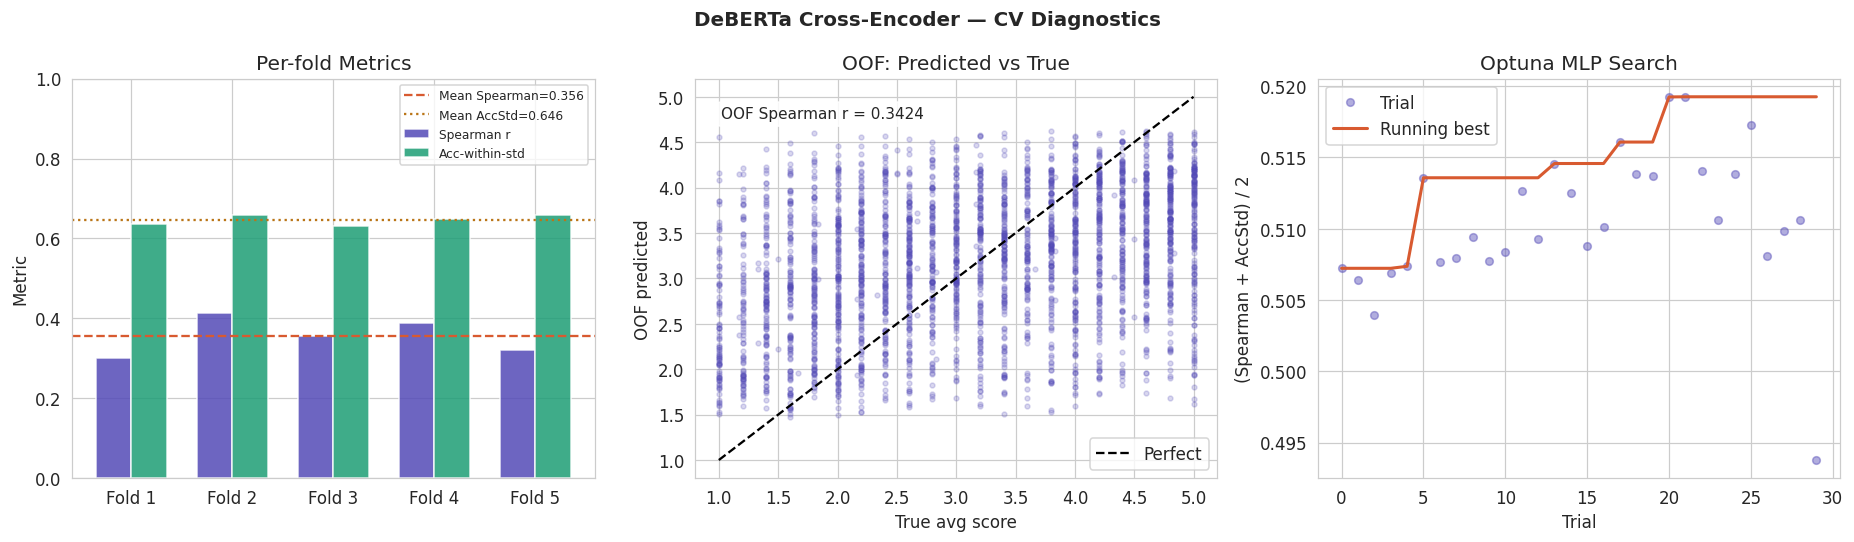

  +  [20:47:58]  Saved -> diagnostics_cv.png


In [10]:
Log.sep('Training Diagnostics')
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})
PAL = ['#534AB7', '#1D9E75', '#D85A30', '#BA7517', '#185FA5']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('DeBERTa Cross-Encoder — CV Diagnostics', fontsize=13,
             fontweight='bold')

# 1. Per-fold Spearman + AccStd bars
ax  = axes[0]
x_f = np.arange(CFG['n_folds'])
w   = 0.35
ax.bar(x_f - w/2, spear_folds, w, label='Spearman r',
       color=PAL[0], alpha=0.85, edgecolor='white')
ax.bar(x_f + w/2, acc_folds,   w, label='Acc-within-std',
       color=PAL[1], alpha=0.85, edgecolor='white')
ax.axhline(np.mean(spear_folds), color=PAL[2], ls='--', lw=1.5,
           label=f'Mean Spearman={np.mean(spear_folds):.3f}')
ax.axhline(np.mean(acc_folds),   color=PAL[3], ls=':',  lw=1.5,
           label=f'Mean AccStd={np.mean(acc_folds):.3f}')
ax.set_xticks(x_f)
ax.set_xticklabels([f'Fold {i+1}' for i in x_f])
ax.set_ylim(0, 1); ax.set_ylabel('Metric')
ax.set_title('Per-fold Metrics'); ax.legend(fontsize=8)

# 2. OOF predicted vs true
ax = axes[1]
ax.scatter(df_cv['average'].values, oof_preds, alpha=0.22, s=10, c=PAL[0])
ax.plot([1, 5], [1, 5], 'k--', lw=1.5, label='Perfect')
ax.text(0.05, 0.93, f'OOF Spearman r = {oof_sp:.4f}',
        transform=ax.transAxes, va='top', fontsize=10,
        bbox=dict(boxstyle='round', fc='white', alpha=0.85))
ax.set_xlabel('True avg score'); ax.set_ylabel('OOF predicted')
ax.set_title('OOF: Predicted vs True'); ax.legend()

# 3. Optuna optimisation history
ax     = axes[2]
values = [t.value for t in study.trials if t.value is not None]
best_r = np.maximum.accumulate(values)
ax.plot(values, 'o', alpha=0.45, color=PAL[0], ms=5, label='Trial')
ax.plot(best_r, '-', color=PAL[2], lw=2, label='Running best')
ax.set_xlabel('Trial'); ax.set_ylabel('(Spearman + AccStd) / 2')
ax.set_title('Optuna MLP Search'); ax.legend()

plt.tight_layout()
plt.savefig('diagnostics_cv.png', bbox_inches='tight', dpi=110)
plt.show()
Log.ok("Saved -> diagnostics_cv.png")

## Cell 11 — Test Inference & Submission


============== Test Inference — Ensemble of Fold Models ==============
  +  [20:47:58]  Test predictions  shape: (930,)  mean: 3.186  std: 0.645  range: [1.833, 4.357]
  +  [20:47:58]  submission.csv saved — 930 rows
  i  [20:47:58]  Head:
 id  average
  0 3.483041
  1 3.866011
  2 3.299168
  3 3.528392
  4 3.664917
  5 3.846529
  6 2.141642
  7 2.536423
  8 2.436760
  9 2.801072


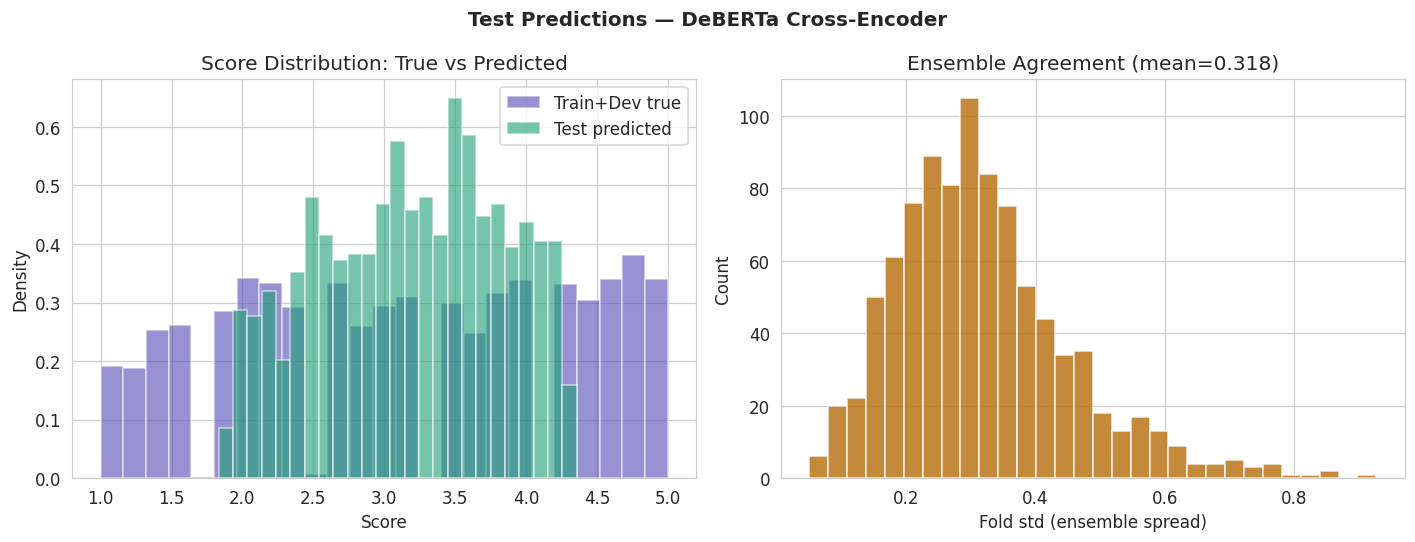

  +  [20:47:58]  Saved -> submission_diagnostics.png

============================== All Done ==============================
  +  [20:47:58]  Outputs: submission.csv | diagnostics_cv.png | submission_diagnostics.png


In [11]:
Log.sep('Test Inference — Ensemble of Fold Models')

# Ensemble = simple mean across folds (test predictions were collected above)
test_preds = np.stack(test_fold_preds, axis=0).mean(axis=0)
test_preds = np.clip(test_preds, 1.0, 5.0)

Log.ok(f"Test predictions  shape: {test_preds.shape}  "
       f"mean: {test_preds.mean():.3f}  std: {test_preds.std():.3f}  "
       f"range: [{test_preds.min():.3f}, {test_preds.max():.3f}]")

submission = pd.DataFrame({
    'id'     : test_df['idx'].values,
    'average': test_preds,
}).sort_values('id').reset_index(drop=True)
submission.to_csv('submission.csv', index=False)
Log.ok(f"submission.csv saved — {len(submission)} rows")
Log.info(f"Head:\n{submission.head(10).to_string(index=False)}")

# Distribution comparison plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Test Predictions — DeBERTa Cross-Encoder', fontsize=13,
             fontweight='bold')

ax = axes[0]
ax.hist(traindev_df['average'], bins=25, color=PAL[0], alpha=0.6,
        label='Train+Dev true', density=True, edgecolor='white')
ax.hist(test_preds, bins=25, color=PAL[1], alpha=0.6,
        label='Test predicted', density=True, edgecolor='white')
ax.set_xlabel('Score'); ax.set_ylabel('Density')
ax.set_title('Score Distribution: True vs Predicted')
ax.legend()

ax = axes[1]
fold_stack = np.stack(test_fold_preds, axis=0)
fold_std   = fold_stack.std(axis=0)
ax.hist(fold_std, bins=30, color=PAL[3], alpha=0.85, edgecolor='white')
ax.set_xlabel('Fold std (ensemble spread)')
ax.set_ylabel('Count')
ax.set_title(f'Ensemble Agreement (mean={fold_std.mean():.3f})')

plt.tight_layout()
plt.savefig('submission_diagnostics.png', bbox_inches='tight', dpi=110)
plt.show()
Log.ok("Saved -> submission_diagnostics.png")

Log.sep('All Done')
Log.ok("Outputs: submission.csv | diagnostics_cv.png | submission_diagnostics.png")